# Day 4-5: Text Classification with scikit-learn 📚

Welcome to the advanced text classification module! In this notebook, we'll explore various machine learning algorithms for text classification using scikit-learn.

## Learning Objectives
- Understand different text classification algorithms
- Implement and compare multiple ML models
- Learn about model evaluation and hyperparameter tuning
- Handle multi-class classification problems
- Build a production-ready text classifier

## What You'll Learn
1. **Classification Algorithms**: Naive Bayes, SVM, Random Forest, Logistic Regression
2. **Model Evaluation**: Cross-validation, classification metrics
3. **Hyperparameter Tuning**: Grid search and random search
4. **Feature Engineering**: Advanced text features
5. **Model Persistence**: Saving and loading trained models

## 1. Setup and Imports

In [1]:
# Standard library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
    
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ All imports successful!")

✅ All imports successful!


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\piers\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Data Preparation

Let's create a comprehensive dataset for text classification with multiple categories.

In [2]:
# Create a multi-class text classification dataset
def create_sample_dataset():
    """Create a sample dataset with multiple text categories"""
    
    # Technology texts
    tech_texts = [
        "The new smartphone features advanced AI capabilities and 5G connectivity.",
        "Machine learning algorithms are revolutionizing data analysis.",
        "Cloud computing provides scalable infrastructure for modern applications.",
        "Blockchain technology ensures secure and transparent transactions.",
        "Virtual reality is transforming the gaming and entertainment industry.",
        "The Internet of Things connects devices for smart home automation.",
        "Cybersecurity measures protect against digital threats and attacks.",
        "Software development follows agile methodologies for better results.",
        "Data science combines statistics and programming for insights.",
        "Artificial intelligence is the future of automation and decision-making."
    ]
    
    # Sports texts
    sports_texts = [
        "The team won the championship with an outstanding performance.",
        "Football players train rigorously to improve their skills.",
        "Basketball requires teamwork and strategic planning.",
        "Tennis players compete in international tournaments worldwide.",
        "Swimming is an excellent exercise for cardiovascular health.",
        "Athletes follow strict diets to maintain peak physical condition.",
        "The Olympic Games bring together athletes from around the world.",
        "Soccer is the most popular sport globally with millions of fans.",
        "Baseball has a rich history in American sports culture.",
        "Golf requires precision and mental focus for success."
    ]
    
    # Business texts
    business_texts = [
        "The company reported strong quarterly earnings and growth.",
        "Marketing strategies focus on customer engagement and retention.",
        "Financial planning helps businesses manage resources effectively.",
        "Leadership skills are essential for successful business management.",
        "Market research provides insights into consumer behavior.",
        "Entrepreneurship requires innovation and risk-taking abilities.",
        "Supply chain management optimizes product delivery and costs.",
        "Human resources handle employee recruitment and development.",
        "Strategic planning guides long-term business objectives.",
        "Customer service excellence drives business success and loyalty."
    ]
    
    # Entertainment texts
    entertainment_texts = [
        "The movie received critical acclaim for its innovative storytelling.",
        "Music festivals bring together artists and fans from diverse backgrounds.",
        "Television shows entertain audiences with compelling narratives.",
        "Video games offer immersive experiences and interactive storytelling.",
        "Comedy shows provide laughter and entertainment for all ages.",
        "Drama series explore complex human emotions and relationships.",
        "Action movies feature spectacular stunts and thrilling sequences.",
        "Documentaries educate viewers about real-world topics and events.",
        "Reality TV shows capture authentic moments and human interactions.",
        "Animation appeals to audiences of all ages with creative storytelling."
    ]
    
    # Combine all texts and labels
    texts = (
        tech_texts + 
        sports_texts + 
        business_texts + 
        entertainment_texts
    )
    # Create category for every text:
    labels = (
        ['technology'] * len(tech_texts) + 
        ['sports'] * len(sports_texts) + 
        ['business'] * len(business_texts) + 
        ['entertainment'] * len(entertainment_texts)
    )
    
    # return a simple dataframe:
    return pd.DataFrame({'text': texts, 'category': labels})

# Create the dataset
df = create_sample_dataset()
print(f"Dataset shape: {df.shape}")
print(f"Categories: {df['category'].unique()}")
print(f"\nCategory distribution:")
print(df['category'].value_counts())

# Display sample texts for every category:
print(f"\nSample texts from each category:")
for category in df['category'].unique():
    print(f"\n{category.upper()}:")
    sample_text = df[df['category'] == category]['text'].iloc[0] # fitst text
    print(f"  {sample_text}")

Dataset shape: (40, 2)
Categories: ['technology' 'sports' 'business' 'entertainment']

Category distribution:
category
technology       10
sports           10
business         10
entertainment    10
Name: count, dtype: int64

Sample texts from each category:

TECHNOLOGY:
  The new smartphone features advanced AI capabilities and 5G connectivity.

SPORTS:
  The team won the championship with an outstanding performance.

BUSINESS:
  The company reported strong quarterly earnings and growth.

ENTERTAINMENT:
  The movie received critical acclaim for its innovative storytelling.


## 3. Text Preprocessing Pipeline

Let's create a comprehensive text preprocessing function that combines all the techniques we learned.

In [3]:
class TextPreprocessor:
    """Advanced text preprocessing pipeline"""
    
    def __init__(self, remove_stopwords=True, use_stemming=True, use_lemmatization=False):
        self.remove_stopwords = remove_stopwords
        self.use_stemming = use_stemming
        self.use_lemmatization = use_lemmatization
        
        # Initialize NLTK components
        self.stop_words = set(stopwords.words('english'))
        self.stemmer = PorterStemmer()
        self.lemmatizer = WordNetLemmatizer()
    
    def clean_text(self, text):
        """Clean and normalize text"""
        # Convert to lowercase
        text = text.lower()
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text)
        
        # Remove special characters but keep basic punctuation
        text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\-]', '', text)
        
        # Strip leading/trailing whitespace
        text = text.strip()

        return text
    
    def tokenize_and_process(self, text):
        """Tokenize and apply text processing"""
        # Tokenize
        tokens = word_tokenize(text)
        
        # Remove stopwords
        if self.remove_stopwords:
            tokens = [token for token in tokens if token not in self.stop_words]
        
        # Apply stemming or lemmatization
        if self.use_stemming:
            tokens = [self.stemmer.stem(token) for token in tokens]
        elif self.use_lemmatization:
            tokens = [self.lemmatizer.lemmatize(token) for token in tokens]
        
        return ' '.join(tokens)
    
    def preprocess(self, texts):
        """Preprocess a list of texts"""
        processed_texts = []
        
        for text in texts:
            # Clean text
            cleaned_text = self.clean_text(text)
            
            # Tokenize and process
            processed_text = self.tokenize_and_process(cleaned_text)
            
            processed_texts.append(processed_text)
        
        return processed_texts

# Initialize preprocessor
preprocessor = TextPreprocessor(
    remove_stopwords=True, 
    use_stemming=True, # more faster than Lemmatization, but less precise
    use_lemmatization=False # very slowly compare to Stemming, but with good precision
    )

# Preprocess the dataset
df['processed_text'] = preprocessor.preprocess(df['text'])

print("✅ Text preprocessing completed!")
print(f"\nSample original vs processed text:")
for i in range(3):
    print(f"\nOriginal: {df['text'].iloc[i]}")
    print(f"Processed: {df['processed_text'].iloc[i]}")

✅ Text preprocessing completed!

Sample original vs processed text:

Original: The new smartphone features advanced AI capabilities and 5G connectivity.
Processed: new smartphon featur advanc ai capabl 5g connect .

Original: Machine learning algorithms are revolutionizing data analysis.
Processed: machin learn algorithm revolution data analysi .

Original: Cloud computing provides scalable infrastructure for modern applications.
Processed: cloud comput provid scalabl infrastructur modern applic .


In [4]:
df.head()

,text,category,processed_text
0,The new smartphone features advanced AI capabi...,technology,new smartphon featur advanc ai capabl 5g conne...
1,Machine learning algorithms are revolutionizin...,technology,machin learn algorithm revolution data analysi .
2,Cloud computing provides scalable infrastructu...,technology,cloud comput provid scalabl infrastructur mode...
3,Blockchain technology ensures secure and trans...,technology,blockchain technolog ensur secur transpar tran...
4,Virtual reality is transforming the gaming and...,technology,virtual realiti transform game entertain indus...


## 4. Classification Algorithms Implementation

Now let's implement and compare multiple machine learning algorithms for text classification.

### 4.1 Feature Extraction with TF-IDF

In [5]:
# Create TF-IDF features
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Split the data
X = df['processed_text']
y = df['category']

# Encode labels ['technology', 'sports', 'business', 'entertainment']
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Transform text to TF-IDF features
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Training set shape: {X_train_tfidf.shape}")
print(f"Test set shape: {X_test_tfidf.shape}")
print(f"Feature names: {len(tfidf_vectorizer.get_feature_names_out())}")

Training set shape: (32, 31)
Test set shape: (8, 31)
Feature names: 31


NB: every column rappresent a word used at least one document inside the dataset.

Here below a print of TF-IDF dataset:

In [6]:
pd.DataFrame(
    X_train_tfidf.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
).head()

,age,athlet,bring,bring togeth,busi,custom,data,develop,entertain,fan,...,requir,resourc,show,sport,storytel,strateg,strateg plan,success,togeth,world
0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.510454,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.477432,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.521592,0.521592,0.0,0.0,0.0
3,0.0,0.707107,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.559581,0.0,0.0,0.0,0.0,0.0,...,0.0,0.61134,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0


### 4.2 Implement Multiple Classifiers

In [7]:
# Initialize classifiers (basic initialization):
classifiers = {
    'Naive Bayes (Multinomial)': MultinomialNB(),
    'Naive Bayes (Bernoulli)': BernoulliNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Linear SVM': LinearSVC(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

# Train and evaluate each classifier
results = {}
for name, classifier in classifiers.items():
    print(f"\n🔍 Training {name}...")
    
    # Train the model
    classifier.fit(X_train_tfidf, y_train)
    
    # Make predictions and probability:
    y_pred = classifier.predict(X_test_tfidf)
    y_pred_proba = classifier.predict_proba(X_test_tfidf) if hasattr(classifier, 'predict_proba') else None
    
    # Calculate metrics (accuracy, precision, recall and fscore):
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    # Store results to the dictionary
    results[name] = {
        'classifier': classifier, # model 
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': y_pred,
        'predictions_proba': y_pred_proba
    }
    
    print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}")

# Display results summary
results_df = pd.DataFrame({
    'Classifier': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'Precision': [results[name]['precision'] for name in results.keys()],
    'Recall': [results[name]['recall'] for name in results.keys()],
    'F1-Score': [results[name]['f1_score'] for name in results.keys()]
})

print(f"\n📊 Classification Results Summary:")
print(results_df.round(4))


🔍 Training Naive Bayes (Multinomial)...
✅ Naive Bayes (Multinomial) - Accuracy: 0.3750, F1: 0.2778

🔍 Training Naive Bayes (Bernoulli)...
✅ Naive Bayes (Bernoulli) - Accuracy: 0.3750, F1: 0.2778

🔍 Training Logistic Regression...
✅ Logistic Regression - Accuracy: 0.5000, F1: 0.4583

🔍 Training Linear SVM...
✅ Linear SVM - Accuracy: 0.5000, F1: 0.4583

🔍 Training Random Forest...
✅ Random Forest - Accuracy: 0.3750, F1: 0.2778

📊 Classification Results Summary:
                  Classifier  Accuracy  Precision  Recall  F1-Score
0  Naive Bayes (Multinomial)     0.375     0.3214   0.375    0.2778
1    Naive Bayes (Bernoulli)     0.375     0.3214   0.375    0.2778
2        Logistic Regression     0.500     0.5833   0.500    0.4583
3                 Linear SVM     0.500     0.5833   0.500    0.4583
4              Random Forest     0.375     0.3214   0.375    0.2778


## 5. Model Evaluation and Analysis

Let's perform comprehensive model evaluation with detailed metrics and visualizations.

### 5.1 Detailed Classification Reports

In [8]:
# Display detailed classification reports
for name, result in results.items():
    print(f"\n{'='*60}")
    print(f"📋 Detailed Report for {name}")
    print(f"{'='*60}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, result['predictions'], 
                              target_names=label_encoder.classes_))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, result['predictions'])
    print(f"\nConfusion Matrix:")
    print(cm)


📋 Detailed Report for Naive Bayes (Multinomial)

Classification Report:
               precision    recall  f1-score   support

     business       0.29      1.00      0.44         2
entertainment       1.00      0.50      0.67         2
       sports       0.00      0.00      0.00         2
   technology       0.00      0.00      0.00         2

     accuracy                           0.38         8
    macro avg       0.32      0.38      0.28         8
 weighted avg       0.32      0.38      0.28         8


Confusion Matrix:
[[2 0 0 0]
 [1 1 0 0]
 [2 0 0 0]
 [2 0 0 0]]

📋 Detailed Report for Naive Bayes (Bernoulli)

Classification Report:
               precision    recall  f1-score   support

     business       1.00      0.50      0.67         2
entertainment       0.00      0.00      0.00         2
       sports       0.00      0.00      0.00         2
   technology       0.29      1.00      0.44         2

     accuracy                           0.38         8
    macro avg    

All the models don't have enoght data to be able to perform well...

### 5.2 Visualization of Results

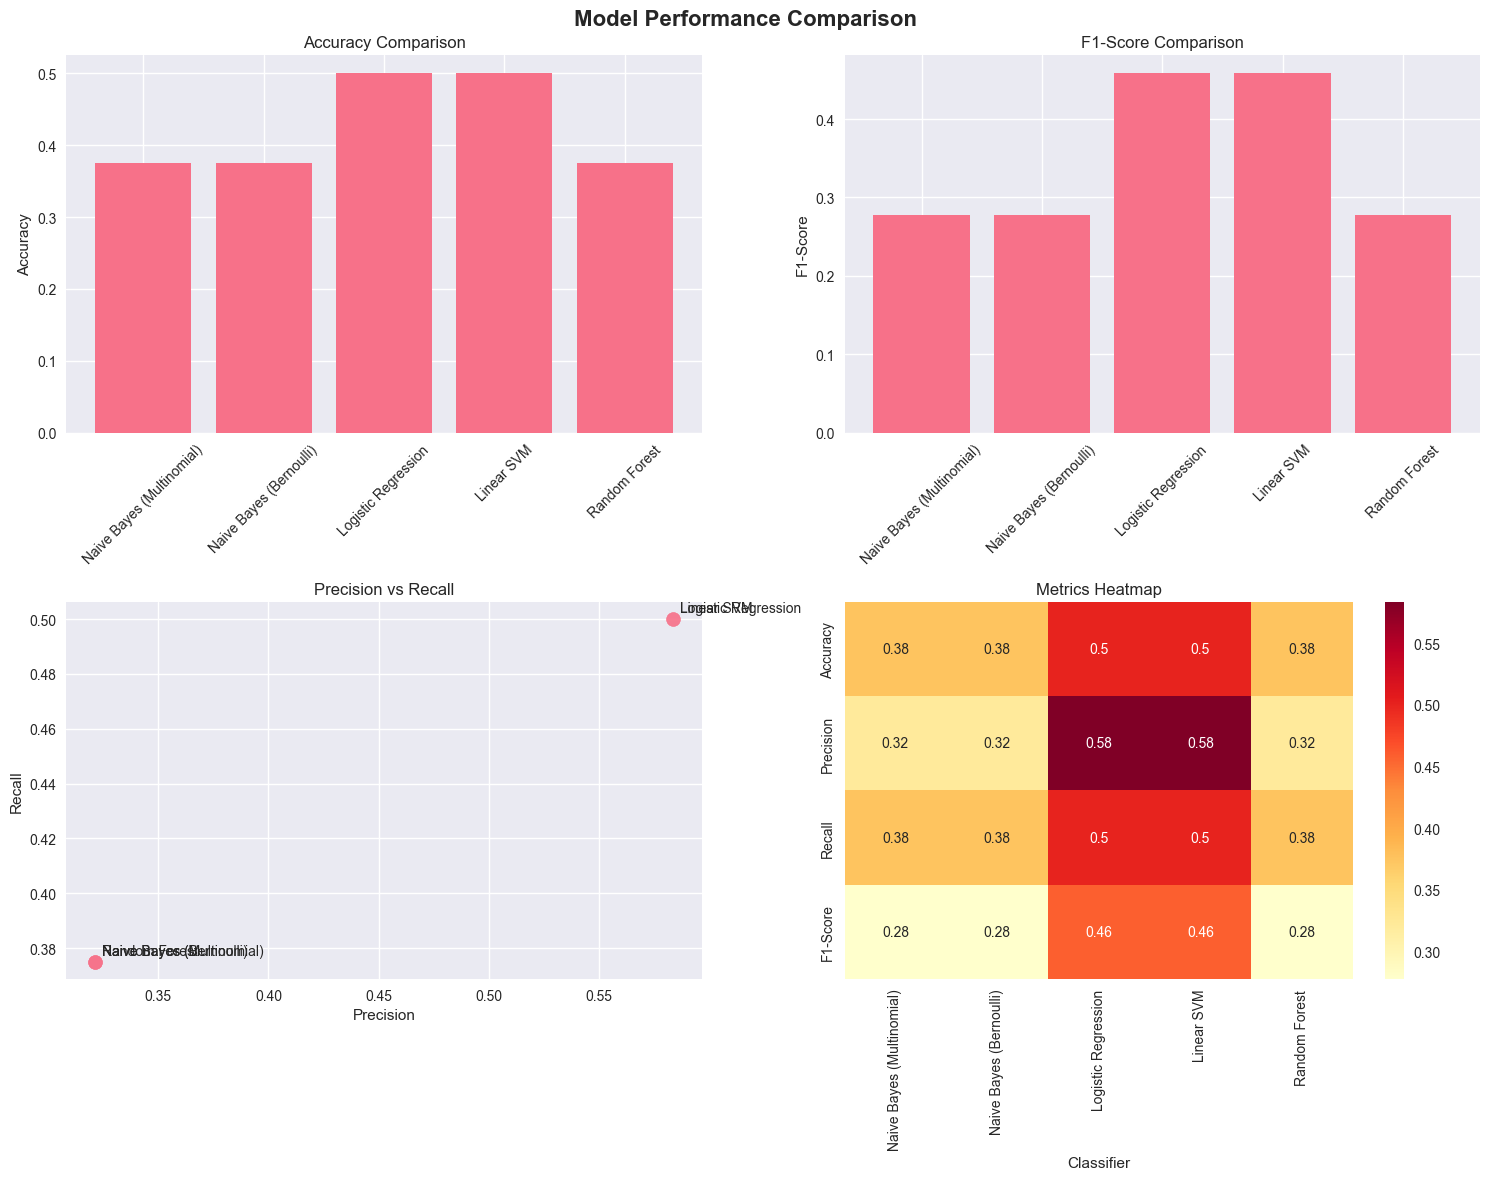

In [9]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Accuracy comparison
axes[0, 0].bar(results.keys(), [results[name]['accuracy'] for name in results.keys()])
axes[0, 0].set_title('Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# F1-Score comparison
axes[0, 1].bar(results.keys(), [results[name]['f1_score'] for name in results.keys()])
axes[0, 1].set_title('F1-Score Comparison')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].tick_params(axis='x', rotation=45)

# Precision vs Recall
axes[1, 0].scatter([results[name]['precision'] for name in results.keys()],
                   [results[name]['recall'] for name in results.keys()],
                   s=100, alpha=0.7)
for i, name in enumerate(results.keys()):
    axes[1, 0].annotate(name, 
                        (results[name]['precision'], results[name]['recall']),
                        xytext=(5, 5), textcoords='offset points')
axes[1, 0].set_xlabel('Precision')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Precision vs Recall')

# Metrics heatmap
metrics_data = results_df.set_index('Classifier')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
sns.heatmap(metrics_data.T, annot=True, cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Metrics Heatmap')

plt.tight_layout()
plt.show()

### 5.3 Cross-Validation Analysis

In [10]:
# Perform cross-validation for more robust evaluation
cv_results = {}
for name, classifier in classifiers.items():
    print(f"\n🔄 Performing cross-validation for {name}...")
    
    # Cross-validation scores
    cv_scores = cross_val_score(classifier, X_train_tfidf, y_train, cv=5, scoring='accuracy')
    
    cv_results[name] = {
        'mean_cv_score': cv_scores.mean(),
        'std_cv_score': cv_scores.std(),
        'cv_scores': cv_scores
    }
    
    print(f"✅ {name} - CV Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Display CV results
cv_df = pd.DataFrame({
    'Classifier': list(cv_results.keys()),
    'CV Mean Score': [cv_results[name]['mean_cv_score'] for name in cv_results.keys()],
    'CV Std Score': [cv_results[name]['std_cv_score'] for name in cv_results.keys()]
})

print(f"\n📊 Cross-Validation Results:")
print(cv_df.round(4))


🔄 Performing cross-validation for Naive Bayes (Multinomial)...
✅ Naive Bayes (Multinomial) - CV Mean: 0.3048 (+/- 0.3644)

🔄 Performing cross-validation for Naive Bayes (Bernoulli)...
✅ Naive Bayes (Bernoulli) - CV Mean: 0.3667 (+/- 0.3389)

🔄 Performing cross-validation for Logistic Regression...
✅ Logistic Regression - CV Mean: 0.3095 (+/- 0.2711)

🔄 Performing cross-validation for Linear SVM...
✅ Linear SVM - CV Mean: 0.3429 (+/- 0.3769)

🔄 Performing cross-validation for Random Forest...
✅ Random Forest - CV Mean: 0.4000 (+/- 0.3802)

📊 Cross-Validation Results:
                  Classifier  CV Mean Score  CV Std Score
0  Naive Bayes (Multinomial)         0.3048        0.1822
1    Naive Bayes (Bernoulli)         0.3667        0.1694
2        Logistic Regression         0.3095        0.1355
3                 Linear SVM         0.3429        0.1884
4              Random Forest         0.4000        0.1901


## 6. Hyperparameter Tuning

Let's optimize the best performing models using grid search and random search.

### 6.1 Grid Search for Logistic Regression

In [11]:
# Grid search for Logistic Regression
print("🔍 Performing Grid Search for Logistic Regression...")

lr_param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    lr_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

lr_grid_search.fit(X_train_tfidf, y_train)

print(f"✅ Best parameters: {lr_grid_search.best_params_}")
print(f"✅ Best CV score: {lr_grid_search.best_score_:.4f}")

# Evaluate tuned model
lr_tuned = lr_grid_search.best_estimator_
lr_tuned_pred = lr_tuned.predict(X_test_tfidf)
lr_tuned_accuracy = accuracy_score(y_test, lr_tuned_pred)
print(f"✅ Tuned model accuracy: {lr_tuned_accuracy:.4f}")

🔍 Performing Grid Search for Logistic Regression...
✅ Best parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
✅ Best CV score: 0.4565
✅ Tuned model accuracy: 0.5000


### 6.2 Random Search for Random Forest

In [12]:
# Random search for Random Forest
print("\n🔍 Performing Random Search for Random Forest...")

rf_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train_tfidf, y_train)

print(f"✅ Best parameters: {rf_random_search.best_params_}")
print(f"✅ Best CV score: {rf_random_search.best_score_:.4f}")

# Evaluate tuned model
rf_tuned = rf_random_search.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test_tfidf)
rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
print(f"✅ Tuned model accuracy: {rf_tuned_accuracy:.4f}")


🔍 Performing Random Search for Random Forest...
✅ Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
✅ Best CV score: 0.5051
✅ Tuned model accuracy: 0.3750


## 7. Advanced Feature Engineering

Let's explore additional text features to improve classification performance.

### 7.1 Additional Text Features

In [26]:
# Create additional text features
def extract_text_features(texts):
    """Extract additional text features:

        - 'word_count'
        - 'char_count'
        - 'avg_word_length'
        - 'special_chars'
        - 'upper_count'
        - 'lower_count'

    """
    features = []
    
    for text in texts:
        # Basic statistics for text:
        word_count = len(text.split())
        char_count = len(text)
        avg_word_length = char_count / word_count if word_count > 0 else 0
        
        # Special character counts (space and number aren't special char...):
        special_chars = sum(1 for c in text if not c.isalnum() and not c.isspace())
        
        # Count capitalization and non-capitalization charcter:
        upper_count = sum(1 for c in text if c.isupper())
        lower_count = sum(1 for c in text if c.islower())
        
        # New features:
        features.append({
            'word_count': word_count, #
            'char_count': char_count,
            'avg_word_length': avg_word_length,
            'special_chars': special_chars,
            'upper_count': upper_count,
            'lower_count': lower_count
        })
    
    return pd.DataFrame(features)

# Extract features ('processed_text' already cleaned):
text_features = extract_text_features(df['processed_text'])
print(f"✅ Extracted {text_features.shape[1]} additional text features")

# Combine TF-IDF with additional features
from scipy.sparse import hstack

# Create additional features for train/test sets
X_train_features = text_features.iloc[X_train.index]
X_test_features = text_features.iloc[X_test.index]

# Combine TF-IDF with additional features
X_train_combined = hstack([X_train_tfidf, X_train_features])
X_test_combined = hstack([X_test_tfidf, X_test_features])

# now 6 more features:
print(f"Combined features shape - Train: {X_train_combined.shape}, Test: {X_test_combined.shape}")

✅ Extracted 6 additional text features
Combined features shape - Train: (32, 37), Test: (8, 37)


### 7.2 Model with Combined Features

In [27]:
# Train model with combined features
print("🔍 Training model with combined features...")

lr_combined = LogisticRegression(random_state=42, max_iter=1000, C=10, penalty='l2')
lr_combined.fit(X_train_combined, y_train)

# Evaluate
lr_combined_pred = lr_combined.predict(X_test_combined)
lr_combined_accuracy = accuracy_score(y_test, lr_combined_pred)
lr_combined_f1 = precision_recall_fscore_support(y_test, lr_combined_pred, average='weighted')[2]

print(f"✅ Combined features model - Accuracy: {lr_combined_accuracy:.4f}, F1: {lr_combined_f1:.4f}")

# Compare with original TF-IDF model
lr_original_accuracy = accuracy_score(y_test, lr_tuned_pred)
lr_original_f1 = precision_recall_fscore_support(y_test, lr_tuned_pred, average='weighted')[2]

print(f"📊 Feature Engineering Impact:")
print(f"   Original TF-IDF - Accuracy: {lr_original_accuracy:.4f}, F1: {lr_original_f1:.4f}")
print(f"   Combined Features - Accuracy: {lr_combined_accuracy:.4f}, F1: {lr_combined_f1:.4f}")
print(f"   Improvement - Accuracy: {lr_combined_accuracy - lr_original_accuracy:+.4f}, F1: {lr_combined_f1 - lr_original_f1:+.4f}")

🔍 Training model with combined features...
✅ Combined features model - Accuracy: 0.5000, F1: 0.4917
📊 Feature Engineering Impact:
   Original TF-IDF - Accuracy: 0.5000, F1: 0.4583
   Combined Features - Accuracy: 0.5000, F1: 0.4917
   Improvement - Accuracy: +0.0000, F1: +0.0333


## 8. Model Persistence and Production Readiness

Let's save the best models and create a production-ready pipeline.

### 8.1 Save Best Models

In [ ]:
import joblib
import pickle

# Create models directory if it doesn't exist
import os
os.makedirs('models', exist_ok=True)

# Save the best models
print("💾 Saving best models...")
model_list = zip(['lr_combined', 'rg_random_search'],[lr_combined, rf_random_search])
for filename, model in model_list:
    filename += ".pkl"
    with open(filename, "wb") as file:
        pickle.dump(model, file)


In [ ]:
# Load the model from the file
filename_load = "rg_random_search.pkl"
with open(filename_load, "rb") as file:
    loaded_model = pickle.load(file)

print(loaded_model)